In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

In [34]:
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score
)

In [35]:
df = pd.read_csv("diabetic_data.csv")

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset shape: (101766, 50)

First 5 rows:
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  .

In [36]:
df["target"] = (df["readmitted"] == "<30").astype(int)

print("\nTarget distribution:")
print(df["target"].value_counts())

print("\nTarget percentage:")
print(df["target"].value_counts(normalize=True) * 100)


Target distribution:
target
0    90409
1    11357
Name: count, dtype: int64

Target percentage:
target
0    88.840084
1    11.159916
Name: proportion, dtype: float64


In [37]:
df = df.drop(
    columns=["encounter_id", "patient_nbr", "readmitted"]
)

In [38]:
features = [
    "race",
    "gender",
    "age",

    # Hospitalization
    "time_in_hospital",

    # Clinical / treatment information
    "num_lab_procedures",
    "num_procedures",
    "num_medications",

    # Previous visits
    "number_outpatient",
    "number_emergency",
    "number_inpatient",

    # Diagnosis
    "diag_1",
    "diag_2",
    "diag_3",

    # Number of diagnoses
    "number_diagnoses",

    # Clinical measurements
    "max_glu_serum",
    "A1Cresult",

    # Diabetes treatment
    "insulin",
    "change",
    "diabetesMed"
]


X = df[features]
y = df["target"]


print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)



Feature matrix shape: (101766, 19)
Target shape: (101766,)


In [39]:
numerical_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]


In [40]:
categorical_features = [
    "race",
    "gender",
    "age",
    "diag_1",
    "diag_2",
    "diag_3",
    "max_glu_serum",
    "A1Cresult",
    "insulin",
    "change",
    "diabetesMed"
]


In [41]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,  random_state=42, stratify=y)
print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 81412
Testing samples: 20354


In [42]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())])



In [43]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore"))])



In [44]:
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])


In [45]:
model = LogisticRegression(
    penalty="l2",
    max_iter=1000,
    solver="liblinear")

In [46]:
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", model)
])


In [47]:
print("\nTraining model...")

pipeline.fit(X_train, y_train)

print("Model training completed!")



Training model...
Model training completed!


In [48]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

In [49]:
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy, 4))

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", round(roc_auc, 4))


Accuracy: 0.8884
ROC-AUC: 0.6418


In [50]:
precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))


Precision: 0.5
Recall: 0.0203


In [51]:
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Not readmitted within 30 days",
            "Readmitted within 30 days"
        ],
        zero_division=0
    )
)


Classification Report:
                               precision    recall  f1-score   support

Not readmitted within 30 days       0.89      1.00      0.94     18083
    Readmitted within 30 days       0.50      0.02      0.04      2271

                     accuracy                           0.89     20354
                    macro avg       0.70      0.51      0.49     20354
                 weighted avg       0.85      0.89      0.84     20354



In [52]:
cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(cm)

print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)


Confusion Matrix:
[[18037    46]
 [ 2225    46]]

True Negatives : 18037
False Positives: 46
False Negatives: 2225
True Positives : 46


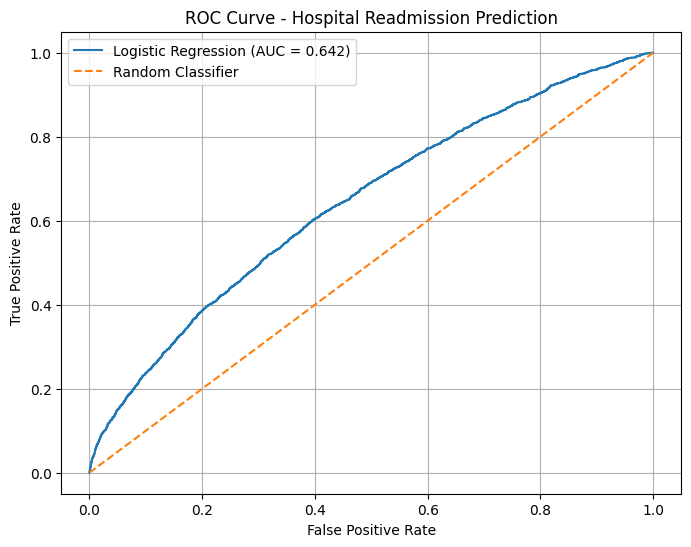

In [53]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr,tpr,label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Hospital Readmission Prediction")

plt.legend()
plt.grid()

plt.show()

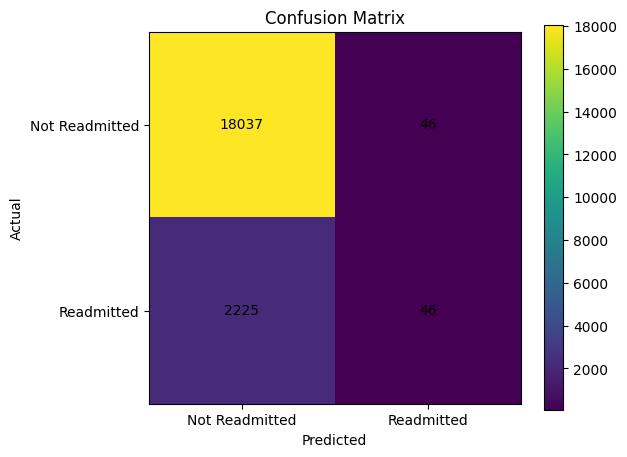

In [54]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Not Readmitted", "Readmitted"]
)

plt.yticks(
    [0, 1],
    ["Not Readmitted", "Readmitted"]
)

# Display numbers inside matrix
for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()


In [55]:
print("\n" + "=" * 60)
print("CLINICAL COST ANALYSIS")
print("=" * 60)

print("\nFalse Negatives:", fn)
print("False Positives:", fp)



CLINICAL COST ANALYSIS

False Negatives: 2225
False Positives: 46


In [56]:
threshold = 0.30

y_pred_30 = (y_prob >= threshold).astype(int)

cm_30 = confusion_matrix(y_test, y_pred_30)

tn30, fp30, fn30, tp30 = cm_30.ravel()

recall_30 = recall_score(
    y_test,
    y_pred_30,
    zero_division=0
)

precision_30 = precision_score(
    y_test,
    y_pred_30,
    zero_division=0
)


print("\n" + "=" * 60)
print("THRESHOLD ANALYSIS")
print("=" * 60)

print("\nDefault threshold: 0.50")

print("\nThreshold: 0.30")

print("True Negatives :", tn30)
print("False Positives:", fp30)
print("False Negatives:", fn30)
print("True Positives :", tp30)

print("\nPrecision:", round(precision_30, 4))
print("Recall   :", round(recall_30, 4))



THRESHOLD ANALYSIS

Default threshold: 0.50

Threshold: 0.30
True Negatives : 17815
False Positives: 268
False Negatives: 2114
True Positives : 157

Precision: 0.3694
Recall   : 0.0691


In [57]:
print("\n" + "=" * 60)
print("FINAL MODEL SUMMARY")
print("=" * 60)

print("Dataset shape:", df.shape)
print("Model: Logistic Regression")
print("Regularization: L2")
print("Test size: 20%")
print("ROC-AUC:", round(roc_auc, 4))
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("False Positives:", fp)
print("False Negatives:", fn)


FINAL MODEL SUMMARY
Dataset shape: (101766, 48)
Model: Logistic Regression
Regularization: L2
Test size: 20%
ROC-AUC: 0.6418
Accuracy: 0.8884
Precision: 0.5
Recall: 0.0203
False Positives: 46
False Negatives: 2225
